

# Notebook 



-----------

Before running this notebook, take a look at the _settings.py file. This python script defines paths to data files and directories used in this notebook.
It also defines some configurations, resolutions and options to use when running the script.
Adjust the paths as needed before proceeding with the rest of the notebook.


In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import sys
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline 


sys.path.append('../..') # location of dem4cli package
from demographics4climate import * # to call fxns directly


In [2]:
print(np.__version__)
print(pd.__version__)

1.25.1
2.0.3


In [3]:
# This code can be run using different configurations, different resolutions and different options. Which ones are we using?

flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [4]:
country = 'India'

# If whole country instead of a province, repeat the name of the country here:
state = 'India'

In [5]:
if country == 'India':
    if state == 'India':
        ISO = 'IND'
    elif state == 'Rajasthan':
        ISO = 'IN.RJ'
    elif state == 'Kerala':
        ISO = 'IN.KL'

In [6]:
indicators = ['HI-caution-QDM-v1', 'HI-extreme-caution-QDM-v1', 'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1']
scenarios = ['NGFS-CurPol', 'NGFS-Net-Zero-2050']


In [7]:
# Create a dictionary containing the names of the indicators considered in this notebook

ind_names = {
    'cropfailure': 'crop failures',
    'driedarea': 'droughts',
    'floodedarea': 'floods',    
    'heatwave': 'heatwaves',
    'wildfire': 'wildfires',
    'HI-caution-QDM-v1': 'Heat Index - caution',
    'HI-extreme-caution-QDM-v1': 'Heat Index - extreme caution',
    'HI-danger-QDM-v1': 'Heat Index - danger',
    'HI-extreme-danger-QDM-v1': 'Heat Index - extreme danger'
}

In [8]:
# Create a dictionary containing information about whether the indicators considered in this notebook are expressed in annual values or not

ind_annual_bool = {
    'cropfailure': True,
    'driedarea': True,
    'floodedarea': True,    
    'heatwave': True,
    'wildfire': True,

    'HI-caution-QDM-v1': False,
    'HI-extreme-caution-QDM-v1': False,
    'HI-danger-QDM-v1': False,
    'HI-extreme-danger-QDM-v1': False
}

In [9]:
# We'll run the analysis on a domain that can be specified here: Lat S, Lat N, Lon W, Lon E.

bbox_indiaws = [ 2.00, 40.00, 66.00, 100.00 ]
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]
bbox_iberia = [ 36.00, 44.00, -10.00, 5.00]

## Population preprocessing - life expectancy only

**Old:**

This section take care of loading and preprocessing all demographic data required for the analysis. 
It uses a wrapper function called preprocess_all_country_data and defined in population_demographics.py.

You can have a look at how preprocess_all_country_data is defined to understand which functions it calls and what it does. 
You can also read the Methods part of Grant et al. (2025) or the Supplementary Material of Thiery et al. (2021) to understand what demographic data are used in this analysis and how they are processed for this purpose.

**New:**

If the data is already processed with RIME-X and compatible with dem4cli (i.e. pop-weighted at country units), you only need the life expectancy functions here from dem4cli and only the life expectancy data

See with other emulators how this would be simplest

In [11]:
# load life expectancy data and clean 
df_unwpp = load_unwpp_lifeexpectancy(filepath_lifeexpectancy = filepath_lifeexpectancy) 
# go from 'period' to 'cohort' life expectancy
df_life_expectancy_5 = get_life_expectancies(df_unwpp,
                                        start_birthyear=1950,
                                        end_birthyear=2025)

load_unwpp_lifeexpectancy took 19.32 s
get_life_expectancies took 0.00 s


In [12]:
# Indicate the geographic domain to look at by specifying the argument bbox

# d_countries = preprocess_all_country_data(

#     filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
#     start_birthyear=1950,
#     end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

#     dir_cohortsizes = dir_cohortsizes,  # cohort size data
#     data_source_cohorts='UNWPP2024',
#     extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
#     by_sex=False,                       # NOTE by_sex not implemented
                                            
#     dir_population= dir_population,     # gridded pop data 
#     ssp=2,
#     urbanrural=False,                   # NOTE urbanrural not implemented for v2
#     bbox = bbox_indiaws,

#     filepath_countrymask = filepath_countrymask,
#     data_source_countrymask = 'shapefile',
#     fillcoast=False, 
#     fix_smallislands=False,
    
#     filepath_world_bank = filepath_world_bank_meta, # metadata 
#     filepath_lookuptable = filepath_lookuptable,    # country filtering
#     filter_countries=True,
#     worldbank_filter=True, 
#     )

# df_countries = d_countries['info_pop']
# gdf_country_borders = d_countries['borders'] 
# da_regions = df_countries['region'].unique()
# da_population = d_countries['population_map']
# df_birthyears = d_countries['birth_years'] # NA
# df_life_expectancy_5 = d_countries['life_expectancy_5']
# da_cohort_size = d_countries['cohort_size']
# countries_regions, countries_mask = d_countries['mask']

In [13]:
df_life_expectancy_5

Country,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Wallis and Futuna Islands,Western Sahara,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,73.0935,78.4736,60.3326,71.0196,72.9259,73.986,73.5868,...,76.9994,71.5994,62.5983,68.7405,68.7827,60.0066,58.8167,63.0338,68.3711,67.5054
1951,54.9914,73.117,59.9968,73.3142,78.7848,60.4601,71.3453,73.1271,74.8442,73.7835,...,77.1543,71.7428,63.0074,69.2576,69.2194,60.2678,59.0545,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,73.5873,79.0685,60.5222,71.6498,73.3441,74.3825,73.9763,...,77.303,71.891,63.3789,69.761,69.5801,60.5338,59.2911,63.3482,68.714,67.9825
1953,55.6465,75.0774,59.7686,74.0095,79.449,60.5925,71.9511,73.5912,75.4063,74.1662,...,77.4524,72.0515,63.7587,70.2772,69.953,60.8083,59.5263,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,74.5568,79.7661,60.6646,72.3025,73.8626,75.209,74.3545,...,77.5948,72.2161,64.1316,70.8107,70.2969,61.0874,59.7591,63.7344,69.1736,68.4717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,86.7605,84.3678,79.983,90.9386,75.3352,86.2771,84.7939,84.5935,82.9247,...,85.1394,79.8067,79.167,80.2522,82.4702,86.024,79.8237,78.3779,76.2603,72.3912
2022,76.441,86.923,84.5161,80.1066,91.0655,75.4478,86.4557,84.9577,84.7182,83.0688,...,85.2944,79.9032,79.3171,80.3761,82.5996,86.1649,79.9495,78.4595,76.3663,72.6039
2023,76.5566,87.0848,84.6631,80.2251,91.1889,75.5534,86.6262,85.1138,84.8523,83.2152,...,85.4518,80.0172,79.4741,80.4974,82.723,86.2609,80.0731,78.5283,76.4686,72.8116


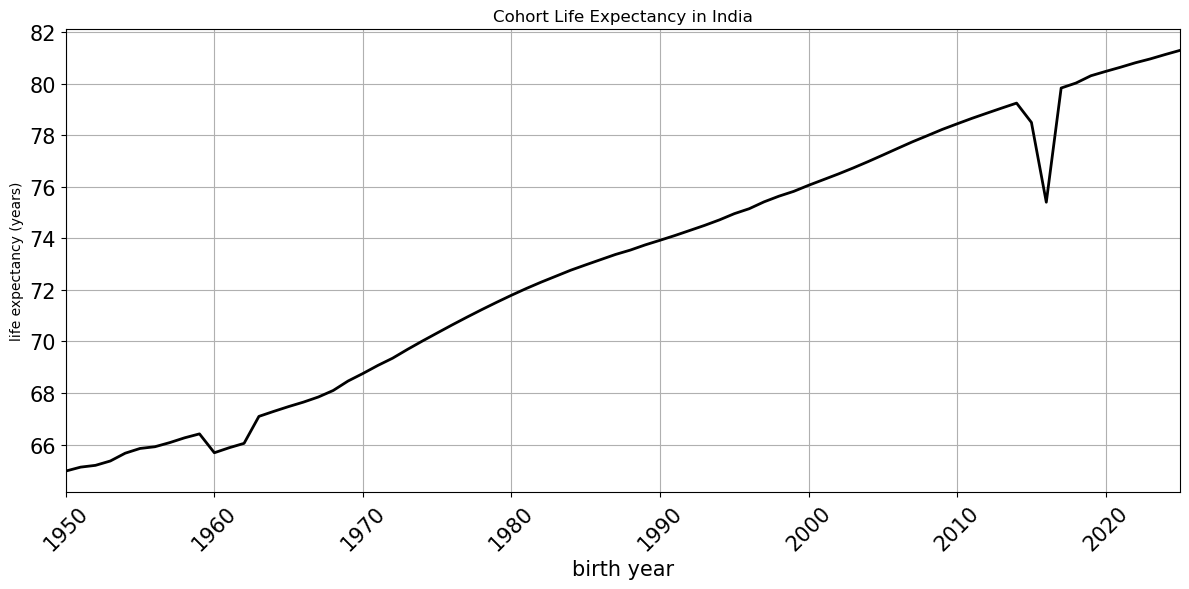

In [14]:
# Extract life expectancy data for the country of interest
life_expectancy_country = df_life_expectancy_5[country]

# Create a plot
plt.figure(figsize=(12, 6))

# Plot the life expectancy over the years
plt.plot(life_expectancy_country.index, life_expectancy_country.values,
         color='black', linewidth=2)

# Customize the plot
plt.title(f'Cohort Life Expectancy in {country}')
plt.xlabel('birth year', fontsize=15)
plt.ylabel('life expectancy (years)')
plt.grid(True)
plt.xticks(ticks=range(life_expectancy_country.index.min(), life_expectancy_country.index.max() + 1, 10),
           rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(life_expectancy_country.index.min(), life_expectancy_country.index.max())

# Show the plot
plt.tight_layout()
plt.show()

## Load population-weighted averages from RIME-X and plot results

In [95]:
# Load results from RIME-X

scenario_names = [scen_name.replace(' ','-') for scen_name in scenarios]
scen_names_stitched = '_'.join(scenario_names)
ind_stitched = '_'.join(indicators)
ISO = ISO.replace('.','-')

# If RIME-X run with constant population, uncomment here:
# path_csvfile = f'/data/brussel/vo/000/bvo00012/vsc11359/data_rime-x/{scen_names_stitched}_{ind_stitched}_{ISO}_pop.csv'

# If RIME-X run with time-evolving population, uncomment here:
path_csvfile = f'/data/brussel/vo/000/bvo00012/vsc11359/data_rime-x/{scen_names_stitched}_{ind_stitched}_{ISO}_ssp2_popweight.csv'

path_csvfile

'/data/brussel/vo/000/bvo00012/vsc11359/data_rime-x/NGFS-CurPol_NGFS-Net-Zero-2050_HI-caution-QDM-v1_HI-extreme-caution-QDM-v1_HI-danger-QDM-v1_HI-extreme-danger-QDM-v1_IND_ssp2_popweight.csv'

In [15]:
df_ts_quantiles = pd.read_csv(path_csvfile)
df_ts_quantiles

NameError: name 'path_csvfile' is not defined

In [16]:
# Exporting from RIME-X into a .csv file messed up the format
# Manually fix that (for now)

#columns = [
#    (                'quantile',                   ''),
#    (                    'year',                   ''),
#    (         'extreme_drought',        'NGFS CurPol'),
#    (         'extreme_drought', 'NGFS Net-Zero 2050'),
#    (               'HI-danger',        'NGFS CurPol'),
#    (               'HI-danger', 'NGFS Net-Zero 2050'),
#    ('heavy_precipitation_days',        'NGFS CurPol'),
#    ('heavy_precipitation_days', 'NGFS Net-Zero 2050'),
#    (                   'fwixd',        'NGFS CurPol'),
#    (                   'fwixd', 'NGFS Net-Zero 2050')
#]

columns = [
    (                'quantile',                   ''),
    (                    'year',                   ''),
    (       'HI-caution-QDM-v1',        'NGFS CurPol'),
    (       'HI-caution-QDM-v1', 'NGFS Net-Zero 2050'),
    ('HI-extreme-caution-QDM-v1',        'NGFS CurPol'),
    ('HI-extreme-caution-QDM-v1', 'NGFS Net-Zero 2050'),
    (        'HI-danger-QDM-v1',        'NGFS CurPol'),
    (        'HI-danger-QDM-v1', 'NGFS Net-Zero 2050'),
    ('HI-extreme-danger-QDM-v1',        'NGFS CurPol'),
    ('HI-extreme-danger-QDM-v1', 'NGFS Net-Zero 2050')
]

#columns = [
#    (   'quantile',                   ''),
#    (       'year',                   ''),
#    (   'heatwave',        'NGFS CurPol'),
#    (   'heatwave', 'NGFS Net-Zero 2050'),
#    (   'wildfire',        'NGFS CurPol'),
#    (   'wildfire', 'NGFS Net-Zero 2050'),
#    ('cropfailure',        'NGFS CurPol'),
#    ('cropfailure', 'NGFS Net-Zero 2050'),
#    ('floodedarea',        'NGFS CurPol'),
#    ('floodedarea', 'NGFS Net-Zero 2050'),
#    (  'driedarea',        'NGFS CurPol'),
#    (  'driedarea', 'NGFS Net-Zero 2050')
#]

df_ts_quantiles.columns = pd.MultiIndex.from_tuples(columns)

NameError: name 'df_ts_quantiles' is not defined

In [17]:
df_ts_quantiles

NameError: name 'df_ts_quantiles' is not defined

In [99]:
print(df_ts_quantiles.columns)
print(df_ts_quantiles.index)
print(df_ts_quantiles.columns.get_level_values(0).unique())
print(df_ts_quantiles['quantile'].unique())

MultiIndex([(                 'quantile',                   ''),
            (                     'year',                   ''),
            (        'HI-caution-QDM-v1',        'NGFS CurPol'),
            (        'HI-caution-QDM-v1', 'NGFS Net-Zero 2050'),
            ('HI-extreme-caution-QDM-v1',        'NGFS CurPol'),
            ('HI-extreme-caution-QDM-v1', 'NGFS Net-Zero 2050'),
            (         'HI-danger-QDM-v1',        'NGFS CurPol'),
            (         'HI-danger-QDM-v1', 'NGFS Net-Zero 2050'),
            ( 'HI-extreme-danger-QDM-v1',        'NGFS CurPol'),
            ( 'HI-extreme-danger-QDM-v1', 'NGFS Net-Zero 2050')],
           )
RangeIndex(start=0, stop=1051, step=1)
Index(['quantile', 'year', 'HI-caution-QDM-v1', 'HI-extreme-caution-QDM-v1',
       'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1'],
      dtype='object')
[ nan 0.5  0.05 0.1  0.25 0.75 0.9  0.95]


In [101]:
## Process dataframe for easier manipulation and plotting
# Ensure 'year' is numeric (if it's a string, convert it)
df_ts_quantiles = df_ts_quantiles.apply(pd.to_numeric, errors='coerce')

# Sort the DataFrame by 'year' for efficient filtering
df_ts_quantiles = df_ts_quantiles.sort_values('year')

# Melt the DataFrame to long format for easier plotting
df_ts_quantiles_melted = df_ts_quantiles.melt(
    id_vars=[
        ('quantile', ''),  # Preserve the quantile column
        ('year', '')       # Preserve the year column
    ],
    #value_vars=[
    #    ('extreme_drought', 'NGFS CurPol'),
    #    ('extreme_drought', 'NGFS Net-Zero 2050'),
    #    ('HI-danger', 'NGFS CurPol'),
    #    ('HI-danger', 'NGFS Net-Zero 2050'),
    #    ('heavy_precipitation_days', 'NGFS CurPol'),
    #    ('heavy_precipitation_days', 'NGFS Net-Zero 2050'),
    #    ('fwixd', 'NGFS CurPol'),
    #    ('fwixd', 'NGFS Net-Zero 2050')
    #],
    
    value_vars=[
        ('HI-caution-QDM-v1', 'NGFS CurPol'),
        ('HI-caution-QDM-v1', 'NGFS Net-Zero 2050'),
        ('HI-extreme-caution-QDM-v1', 'NGFS CurPol'),
        ('HI-extreme-caution-QDM-v1', 'NGFS Net-Zero 2050'),
        ('HI-danger-QDM-v1', 'NGFS CurPol'),
        ('HI-danger-QDM-v1', 'NGFS Net-Zero 2050'),
        ('HI-extreme-danger-QDM-v1', 'NGFS CurPol'),
        ('HI-extreme-danger-QDM-v1', 'NGFS Net-Zero 2050')
    ],
    
    #value_vars=[
    #    (   'heatwave',        'NGFS CurPol'),
    #    (   'heatwave', 'NGFS Net-Zero 2050'),
    #    (   'wildfire',        'NGFS CurPol'),
    #    (   'wildfire', 'NGFS Net-Zero 2050'),
    #    ('cropfailure',        'NGFS CurPol'),
    #    ('cropfailure', 'NGFS Net-Zero 2050'),
    #    ('floodedarea',        'NGFS CurPol'),
    #    ('floodedarea', 'NGFS Net-Zero 2050'),
    #    (  'driedarea',        'NGFS CurPol'),
    #    (  'driedarea', 'NGFS Net-Zero 2050')
    #],

    var_name=['indicator', 'scenario'],
    value_name='value'
)

# Rename the 'year' and 'quantile' columns for clarity
df_ts_quantiles_melted.rename(columns={('year', ''): 'year', ('quantile', ''): 'quantile'}, inplace=True)

In [102]:
df_ts_quantiles_melted

,quantile,year,indicator,scenario,value
0,0.95,1950.0,HI-caution-QDM-v1,NGFS CurPol,297.880586
1,0.05,1950.0,HI-caution-QDM-v1,NGFS CurPol,283.574170
2,0.50,1950.0,HI-caution-QDM-v1,NGFS CurPol,295.211885
3,0.90,1950.0,HI-caution-QDM-v1,NGFS CurPol,297.289053
4,0.10,1950.0,HI-caution-QDM-v1,NGFS CurPol,284.287317
...,...,...,...,...,...
8403,0.05,2099.0,HI-extreme-danger-QDM-v1,NGFS Net-Zero 2050,0.193576
8404,0.95,2099.0,HI-extreme-danger-QDM-v1,NGFS Net-Zero 2050,2.837590
8405,0.10,2099.0,HI-extreme-danger-QDM-v1,NGFS Net-Zero 2050,0.236028
8406,0.90,2099.0,HI-extreme-danger-QDM-v1,NGFS Net-Zero 2050,1.903565


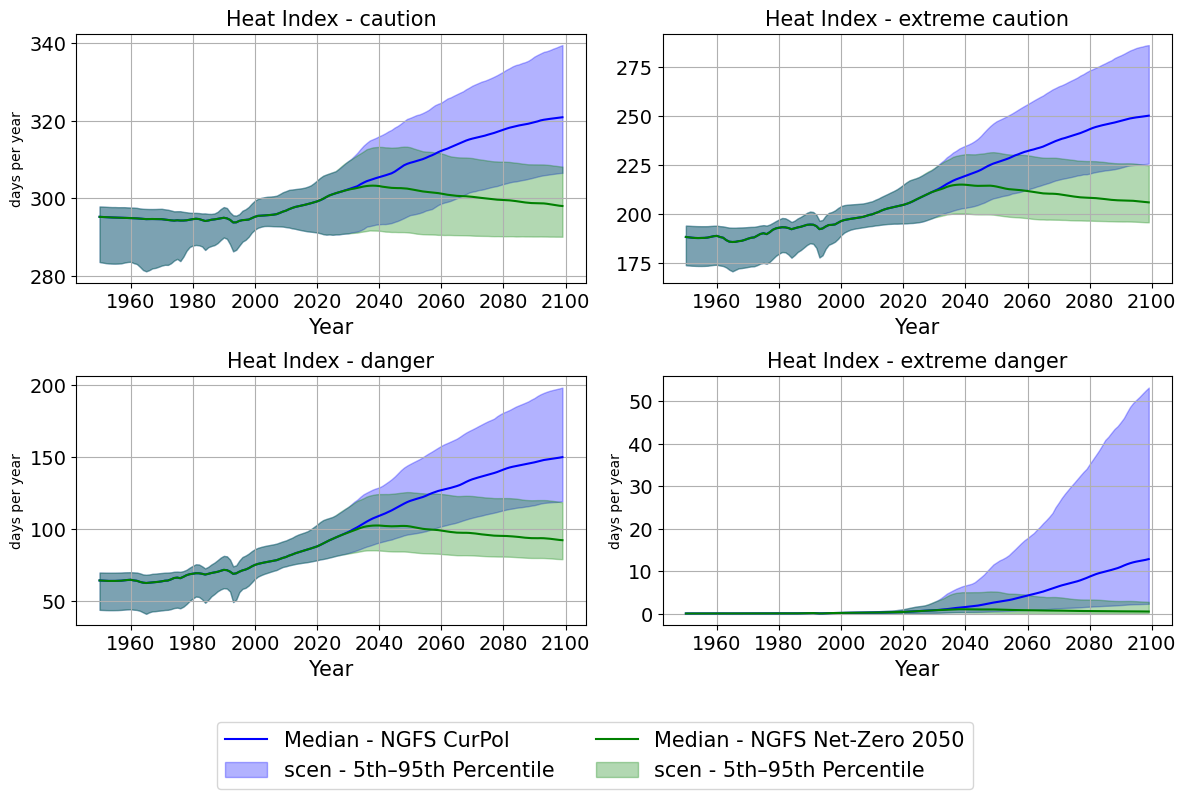

In [106]:
colors = ['blue', 'green']
tick_interval = 20 # set interval for x axis tick for plotting

# Quantiles for plotting
low_quantile = 0.05
high_quantile = 1 - low_quantile

# Get unique indicators
indicator_list = df_ts_quantiles_melted['indicator'].unique()
scenario_list = df_ts_quantiles_melted['scenario'].unique()

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))
#fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
#fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 5))
axs = axs.flatten() if len(indicator_list) > 1 else [axs]

for ind_index, ind in enumerate(indicator_list):

 # Filter data for the current indicator
    indicator_data = df_ts_quantiles_melted[df_ts_quantiles_melted['indicator'] == ind]

    # Loop through each scenario
    for scen_index, scen in enumerate(scenario_list):
        # Filter data for the current scenario
        scen_data = indicator_data[indicator_data['scenario'] == scen]

        # Plot results
        axs[ind_index].plot(scen_data[scen_data['quantile'] == 0.5]['year'], scen_data[scen_data['quantile'] == 0.5]['value'], label=f'Median - {scen}', color=colors[scen_index])
        axs[ind_index].fill_between(scen_data[scen_data['quantile'] == 0.5]['year'], scen_data[scen_data['quantile'] == low_quantile]['value'], scen_data[scen_data['quantile'] == high_quantile]['value'], 
                         color=colors[scen_index], alpha=0.3, label=f'scen - {int(low_quantile*100)}th–{int(high_quantile*100)}th Percentile')

     # Set labels, titles and grid
    axs[ind_index].set_xlabel('Year', fontsize=15)
    axs[ind_index].tick_params(axis='both', labelsize=14)  # Increase tick label font size
    
    if ind in ['HI-caution', 'HI-danger', 'fwixd', 'heavy_precipitation_days', 'HI-caution-QDM-v1', 'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1']:
        axs[ind_index].set_ylabel('days per year')
    elif ind in ['extreme_drought']:
        axs[ind_index].set_ylabel('area affected (%)')

    if country == state:
        #axs[ind_index].set_title(f'{ind} - {country}')
        axs[ind_index].set_title(f'{ind_names[ind]}', fontsize=15)
    else:
        axs[ind_index].set_title(f'{ind} - {state} ({country})')
    axs[ind_index].grid(True)
    axs[ind_index].xaxis.set_major_locator(MultipleLocator(tick_interval))

# Add a column legend
handles, labels = axs[ind_index].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.15), fontsize=15)

plt.tight_layout()
plt.show()

## Run RIME-X 

## Calculate lifetime exposure with a function and plot results



In [110]:
ds_lifetime_exp = calc_lifetime_exposure_rimex(df_life_expectancy_5, 1950, 2010, df_ts_quantiles, country=country)

calc_lifetime_exposure_rimex took 0.03 s


In [111]:
ds_lifetime_exp

<xarray.Dataset>
Dimensions:                    (birth_year: 61, quantile: 7, scenario: 2)
Coordinates:
  * birth_year                 (birth_year) int64 1950 1951 1952 ... 2009 2010
  * quantile                   (quantile) float64 0.05 0.1 0.25 ... 0.9 0.95
  * scenario                   (scenario) object 'NGFS CurPol' 'NGFS Net-Zero...
Data variables:
    HI-caution-QDM-v1          (birth_year, quantile, scenario) object 18644....
    HI-danger-QDM-v1           (birth_year, quantile, scenario) object 3506.7...
    HI-extreme-caution-QDM-v1  (birth_year, quantile, scenario) object 11743....
    HI-extreme-danger-QDM-v1   (birth_year, quantile, scenario) object 4.2756...

In [118]:
# Convert lifetime exposure from cumulated days to cumulated years
#ds_lifetime_exp_toplot = ds_lifetime_exp / 365.25

#for ind, should_not_divide in ind_annual_bool.items():
#    if not should_not_divide:
#        ds_lifetime_exp_toplot[ind] = ds_lifetime_exp[ind] / 365.25
#    else:
#        ds_lifetime_exp_toplot[ind] = ds_lifetime_exp[ind]
ds_lifetime_exp_toplot = xr.Dataset()

for ind in indicators:
    should_not_divide = ind_annual_bool[ind]
    if not should_not_divide:
        ds_lifetime_exp_toplot[ind] = ds_lifetime_exp[ind] / 365.25
    else:
        ds_lifetime_exp_toplot[ind] = ds_lifetime_exp[ind]

In [119]:
ds_lifetime_exp_toplot

<xarray.Dataset>
Dimensions:                    (birth_year: 61, quantile: 7, scenario: 2)
Coordinates:
  * birth_year                 (birth_year) int64 1950 1951 1952 ... 2009 2010
  * quantile                   (quantile) float64 0.05 0.1 0.25 ... 0.9 0.95
  * scenario                   (scenario) object 'NGFS CurPol' 'NGFS Net-Zero...
Data variables:
    HI-caution-QDM-v1          (birth_year, quantile, scenario) object 51.045...
    HI-extreme-caution-QDM-v1  (birth_year, quantile, scenario) object 32.152...
    HI-danger-QDM-v1           (birth_year, quantile, scenario) object 9.6010...
    HI-extreme-danger-QDM-v1   (birth_year, quantile, scenario) object 0.0117...

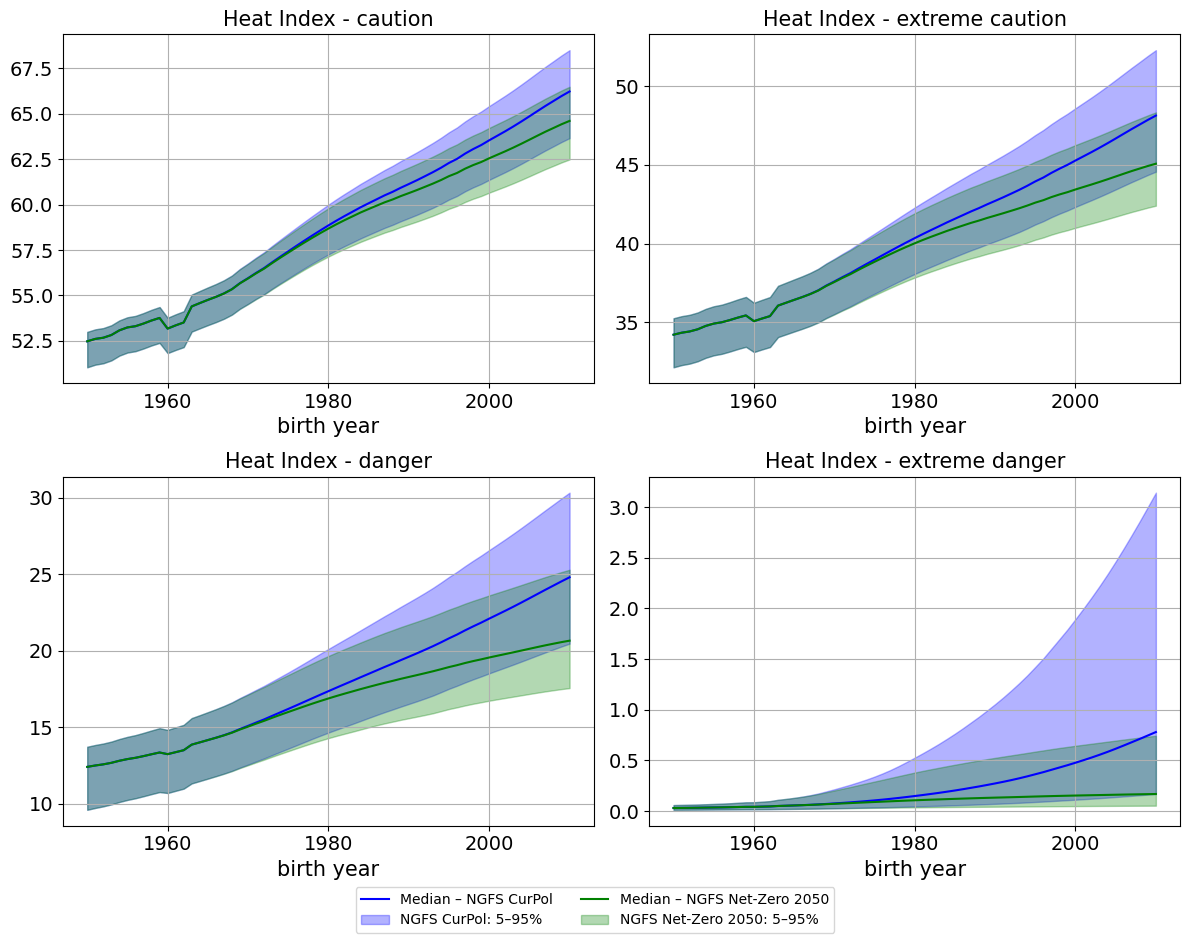

In [120]:
colors = ['blue', 'green']
tick_interval = 20

low_q = 0.05
mid_q = 0.5
high_q = 0.95

scenario_list = ds_lifetime_exp_toplot.scenario.values
indicator_list = list(ds_lifetime_exp_toplot.data_vars)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
#fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
#fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 7))
axs = axs.flatten() if len(indicators) > 1 else [axs]

for ind_idx, ind in enumerate(indicator_list):
    da = ds_lifetime_exp_toplot[ind]

    for scen_idx, scen in enumerate(scenario_list):

        # Select quantiles
        median = da.sel(scenario=scen, quantile=mid_q).values
        low = da.sel(scenario=scen, quantile=low_q).values
        high = da.sel(scenario=scen, quantile=high_q).values
        birth_years = da.birth_year.values

        # Convert to float64 arrays
        median = np.array(median, dtype=np.float64)
        low = np.array(low, dtype=np.float64)
        high = np.array(high, dtype=np.float64)

        # Plot median
        axs[ind_idx].plot(
            birth_years,
            median,
            color=colors[scen_idx],
            label=f'Median – {scen}'
        )

        # Fill uncertainty range
        axs[ind_idx].fill_between(
            birth_years,
            low,
            high,
            color=colors[scen_idx],
            alpha=0.3,
            label=f'{scen}: {int(low_q*100)}–{int(high_q*100)}%'
        )

    # Axis styling
    if country == state:
        #axs[ind_idx].set_title(f'{ind} – {country}')
        axs[ind_idx].set_title(f'{ind_names[ind]}', fontsize=15)
    else:
        axs[ind_idx].set_title(f'{ind} – {state} ({country})')
    axs[ind_idx].set_xlabel('birth year', fontsize=15)
    #axs[ind_idx].set_ylabel('lifetime exposure (years)')
    axs[ind_idx].tick_params(axis='both', labelsize=14)  # Increase tick label font size
    axs[ind_idx].grid(True)
    axs[ind_idx].xaxis.set_major_locator(MultipleLocator(tick_interval))

# Shared legend (column legend)
handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.show()

# OLD: Calculate lifetime exposure by manipulating the dataframe and convert to dataset only at the end

In [20]:
def calc_lifetime_exposure_rimex_df(df_life_expectancy, start_birthyear, end_birthyear, df_ts_quantiles, country='Portugal'):

    # 1. Get all columns except 'quantile' and 'year'
    columns_to_process = [ 
        col for col in df_ts_quantiles.columns
        if col[0] not in ['quantile', 'year']
    ]


    # 2. Determine maximum death year and maximum year currently in the dataframe
    death_years = []
    for birth_yr in range(start_birthyear, end_birthyear + 1):
        life_expectancy = df_life_expectancy.loc[birth_yr, country]
        death_yr = birth_yr + life_expectancy
        death_years.append(death_yr)
    max_death_yr = int(np.floor(max(death_years)))
    current_max_year = df_ts_quantiles[('year', '')].max()  
    

    # 3. If needed, extend the data up until the maximum death year by adding the mean of the last 10 years
    # for all quantiles and columns  
    min_year = int(df_ts_quantiles[('year', '')].min())
    if max_death_yr > current_max_year:

        extended_data_dfs = []

        for quantile in df_ts_quantiles['quantile'].dropna().unique():

            quantile_mask = (df_ts_quantiles['quantile'] == quantile)
            quantile_data = df_ts_quantiles.loc[quantile_mask].copy()

            # Set 'year' as the index for reindexing later
            quantile_data = quantile_data.set_index(('year', ''))

            # Create a new DataFrame with an extended time index 
            extended_index = range(min_year, max_death_yr + 1)
            extended_quantile_data = pd.DataFrame(index=extended_index)

            # Copy the 'year' and 'quantile' columns
            extended_quantile_data[('year', '')] = extended_index
            extended_quantile_data[('quantile', '')] = quantile

            for col in columns_to_process:
                last_10_years_mean = quantile_data[col].iloc[-10:].mean()
                extended_quantile_data[col] = quantile_data[col].reindex(
                    extended_index, fill_value=last_10_years_mean
                )
            
            # Append the extended data to the list
            extended_data_dfs.append(extended_quantile_data)

        # Combine the extended data for all quantiles and rename the 'year' and 'quantile' columns
        df_ts_quantiles = pd.concat(extended_data_dfs)
        df_ts_quantiles.rename(columns={('year', ''): 'year', ('quantile', ''): 'quantile'}, inplace=True)


    # 4. Loop over all birth years to calculate integral over lifetime for each cohort
    d_lifetime_exp = {} 

    for birth_yr in range(start_birthyear, end_birthyear+1):
        
        # Get life expectancy for that specified country and calculate death year
        life_expectancy = df_life_expectancy.loc[birth_yr, country]
        death_yr = birth_yr + np.floor(life_expectancy)

        # Filter for years lived fully, group by quantiles and sum over them
        fullyears_df = df_ts_quantiles[(df_ts_quantiles['year'] >= birth_yr) & (df_ts_quantiles['year'] <= death_yr-1)]
        summed_df = fullyears_df.groupby('quantile').sum()

        # Filter for year lived partially, group by quantiles and multiply the exposure for that year by the fraction of year lived
        # Then add it to summed_df
        partialyear_df = df_ts_quantiles[(df_ts_quantiles['year'] == death_yr)]
        partialexposure_df = partialyear_df.groupby('quantile').sum() * (life_expectancy - np.floor(life_expectancy))
        summed_df = summed_df + partialexposure_df

        # Store the result for this birth year
        summed_df = summed_df.drop(columns=['year'], errors='ignore')
        d_lifetime_exp[birth_yr] = summed_df
    

    # 5. Manipulate the DataFrame before storing into an xarray dataset 
    # Combine dictionary into one big DataFrame 
    df_concat = pd.concat(d_lifetime_exp, names=["birth year", "quantile"]) 

    # Ensure column MultiIndex is named correctly 
    df_concat.columns = pd.MultiIndex.from_tuples(df_concat.columns, names=["indicator", "scenario"] )

    # Convert to xarray: indicator becomes variables, scenario becomes dimension 
    ds_lifetime_exp = df_concat.stack(level="scenario").to_xarray() 
    
    # Rename this dimension 
    ds_lifetime_exp = ds_lifetime_exp.rename({"birth year": "birth_year"})

    return ds_lifetime_exp

# OLD: Calculate lifetime exposure without a function and plot results

In [21]:
# Compute sum over lifetime

start_birthyear = 1950
end_birthyear = 2000

## Initialize a dictionary to store results for each starting year
d_lifetime_exp = {}

# Iterate over each birth year (for each birth cohort)
for birth_yr in range(start_birthyear, end_birthyear+1):

    # Get life expectancy
    life_expectancy = df_life_expectancy_5.loc[birth_yr, 'Portugal']

    # Define death year based on life expectancy
    death_yr = birth_yr + np.floor(life_expectancy)

    # Filter for years lived fully, group by quantiles and sum over them
    fullyears_df = df_ts_quantiles[(df_ts_quantiles['year'] >= birth_yr) & (df_ts_quantiles['year'] <= death_yr-1)]
    summed_df = fullyears_df.groupby('quantile').sum()

    # Filter for year lived partially, group by quantiles and multiply the exposure for that year by the fraction of year lived
    partialyear_df = df_ts_quantiles[(df_ts_quantiles['year'] == death_yr)]
    partialexposure_df = partialyear_df.groupby('quantile').sum() * (life_expectancy - np.floor(life_expectancy))

    # Add the partial exposure to summed_df
    summed_df = summed_df + partialexposure_df

    # Store the result for this starting year
    summed_df = summed_df.drop(columns=['year'], errors='ignore')
    d_lifetime_exp[birth_yr] = summed_df

# Combine all results into a single DataFrame (optional)
df_lifetime_exp = pd.concat(d_lifetime_exp, names=['birth year', 'quantile'])

KeyError: 'Portugal'

In [ ]:
# Process the dataframe with lifetime exposure results for plotting 

# Convert from cumulated days to cumulated years
df_lifetime_exp_years = df_lifetime_exp / 365.25

# Reset the index to convert 'birth year' and 'quantile' into columns
df_lifetime_exp_reset = df_lifetime_exp_years.reset_index()

# Melt the DataFrame to long format
df_lifetime_exp_melted = df_lifetime_exp_reset.melt(
    id_vars=['birth year', 'quantile'],
    var_name=['indicator', 'scenario'],
    value_name='value'
)



In [ ]:
df_lifetime_exp

fwixd                      HI-caution  \
                     NGFS CurPol NGFS Net-Zero 2050  NGFS CurPol   
birth year quantile                                                
1950       0.05      1069.698380        1069.722955  5366.258601   
           0.10      1090.338046        1090.415132  5524.563062   
           0.25      1257.718873        1257.757017  5617.184631   
           0.50      1524.701606        1524.822258  5727.514284   
           0.75      1728.550379        1728.758131  5817.750180   
...                          ...                ...          ...   
2000       0.25      2292.985414        1831.335952  7287.508443   
           0.50      2738.478131        2226.862369  7606.837195   
           0.75      3098.439669        2604.965912  7915.654732   
           0.90      3430.347078        2943.551304  8279.200834   
           0.95      3618.169436        3175.561523  8510.683046   

                                        
                    NGFS Net-Zero 2050  
birth year quantile                     
1950       0.05            5366.253162  
           0.10            5524.623377  
           0.25            5617.267128  
           0.50            5727.635007  
           0.75            5817.971681  
...                                ...  
2000       0.25            6607.268523  
           0.50            6894.276553  
           0.75            7232.917984  
           0.90            7581.560998  
           0.95            7816.148761  

[357 rows x 4 columns]

In [ ]:
print(df_lifetime_exp.columns)
print(df_lifetime_exp.index)

MultiIndex([(     'fwixd',        'NGFS CurPol'),
            (     'fwixd', 'NGFS Net-Zero 2050'),
            ('HI-caution',        'NGFS CurPol'),
            ('HI-caution', 'NGFS Net-Zero 2050')],
           )
MultiIndex([(1950, 0.05),
            (1950,  0.1),
            (1950, 0.25),
            (1950,  0.5),
            (1950, 0.75),
            (1950,  0.9),
            (1950, 0.95),
            (1951, 0.05),
            (1951,  0.1),
            (1951, 0.25),
            ...
            (1999, 0.75),
            (1999,  0.9),
            (1999, 0.95),
            (2000, 0.05),
            (2000,  0.1),
            (2000, 0.25),
            (2000,  0.5),
            (2000, 0.75),
            (2000,  0.9),
            (2000, 0.95)],
           names=['birth year', 'quantile'], length=357)


In [ ]:
df_lifetime_exp_melted

,birth year,quantile,indicator,scenario,value
0,1950,0.05,fwixd,NGFS CurPol,2.928675
1,1950,0.10,fwixd,NGFS CurPol,2.985183
2,1950,0.25,fwixd,NGFS CurPol,3.443447
3,1950,0.50,fwixd,NGFS CurPol,4.174405
4,1950,0.75,fwixd,NGFS CurPol,4.732513
...,...,...,...,...,...
1423,2000,0.25,HI-caution,NGFS Net-Zero 2050,18.089715
1424,2000,0.50,HI-caution,NGFS Net-Zero 2050,18.875500
1425,2000,0.75,HI-caution,NGFS Net-Zero 2050,19.802650
1426,2000,0.90,HI-caution,NGFS Net-Zero 2050,20.757183


In [ ]:
print(df_lifetime_exp_melted.columns)
print(df_lifetime_exp_melted.index)

Index(['birth year', 'quantile', 'indicator', 'scenario', 'value'], dtype='object')
RangeIndex(start=0, stop=1428, step=1)


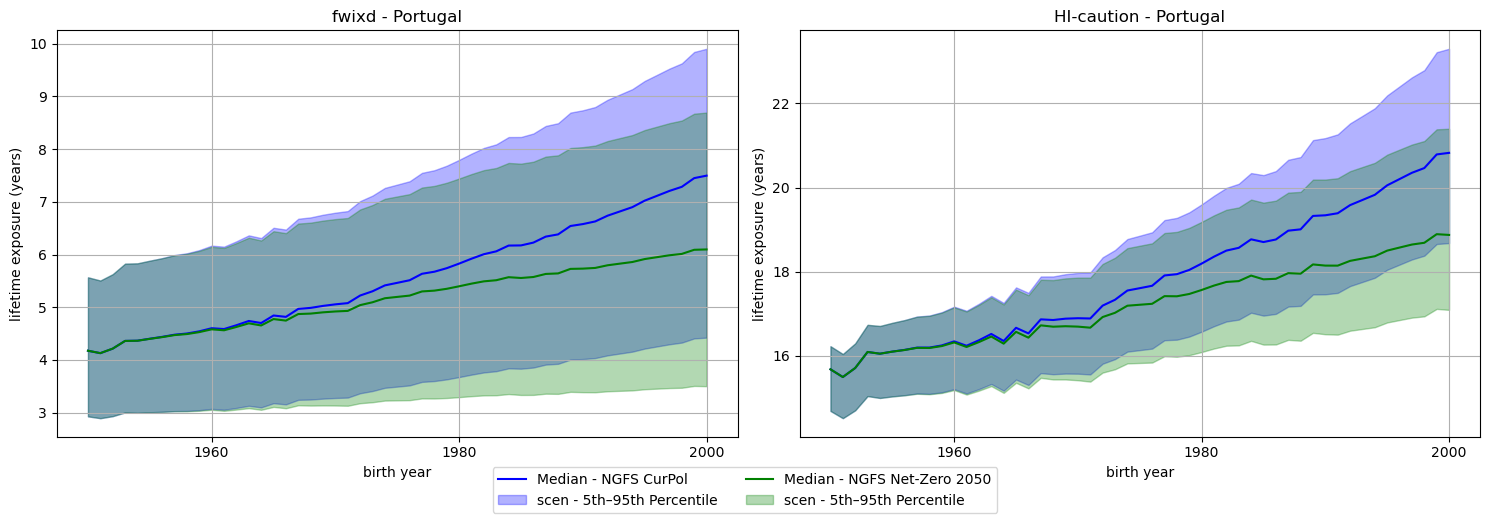

In [ ]:
# Plot the lifetime exposure

colors = ['blue', 'green']
tick_interval = 20 # set interval for x axis tick for plotting

# Quantiles for plotting
low_quantile = 0.05
high_quantile = 1 - low_quantile

# Get unique indicators
indicators = df_ts_quantiles_melted['indicator'].unique()
scenarios = df_ts_quantiles_melted['scenario'].unique()

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axs = axs.flatten() if len(indicators) > 1 else [axs]

for ind_index, ind in enumerate(indicators):

 # Filter data for the current indicator
    indicator_data = df_lifetime_exp_melted[df_lifetime_exp_melted['indicator'] == ind]

    # Loop through each scenario
    for scen_index, scen in enumerate(scenarios):
        # Filter data for the current scenario
        scen_data = indicator_data[indicator_data['scenario'] == scen]

        # Plot the median 
        axs[ind_index].plot(
            scen_data[scen_data['quantile'] == 0.5]['birth year'], 
            scen_data[scen_data['quantile'] == 0.5]['value'], 
            label=f'Median - {scen}', 
            color=colors[scen_index]
            )

        # Plot the uncertainty range            
        axs[ind_index].fill_between(
            scen_data[scen_data['quantile'] == 0.5]['birth year'], 
            scen_data[scen_data['quantile'] == low_quantile]['value'], 
            scen_data[scen_data['quantile'] == high_quantile]['value'], 
            color=colors[scen_index], 
            alpha=0.3, 
            label=f'scen - {int(low_quantile*100)}th–{int(high_quantile*100)}th Percentile')

     # Set labels, titles and grid
    axs[ind_index].set_xlabel('birth year')
    axs[ind_index].set_ylabel('lifetime exposure (years)')
    axs[ind_index].set_title(f'{ind} - Portugal')
    axs[ind_index].grid(True)
    axs[ind_index].xaxis.set_major_locator(MultipleLocator(tick_interval))

# Add a column legend
handles, labels = axs[ind_index].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()